In [ ]:
##prediction

In [1]:
#import Libaries #importation des données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read in California housing dataset.
from sklearn.datasets import fetch_california_housing


housing = fetch_california_housing()

In [8]:
housing.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [10]:
# Import train_test_split.
from sklearn.model_selection import train_test_split


# Create features X and target y.
X = pd.DataFrame(housing.data, columns=housing.feature_names)[["AveRooms"]]
y = housing.target  # Median house value in $100,000s


# Split the dataset into training (80%) and testing (20%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
X.head()

,AveRooms
0,6.984127
1,6.238137
2,8.288136
3,5.817352
4,6.281853


In [12]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [13]:
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler.
scaler = StandardScaler()

# Fit and transform training data.
X_train_scaled = scaler.fit_transform(X_train)

# Also transform test data.
X_test_scaled = scaler.transform(X_test)

In [14]:
# Import LinearRegression.
from sklearn.linear_model import LinearRegression


# Instantiate linear regression model.
model = LinearRegression()

In [15]:
# Fit the model to the training data.
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_pred = model.predict(X_test_scaled)

In [17]:
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score


# Calculate and print R^2 score.
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.4f}")

R-squared: 0.0138


In [18]:
# Calculate and print MSE.
mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.4f}")


# Calculate and print RMSE.
rmse = mse ** 0.5
print(f"Root mean squared error: {rmse:.4f}")

Mean squared error: 1.2923
Root mean squared error: 1.1368


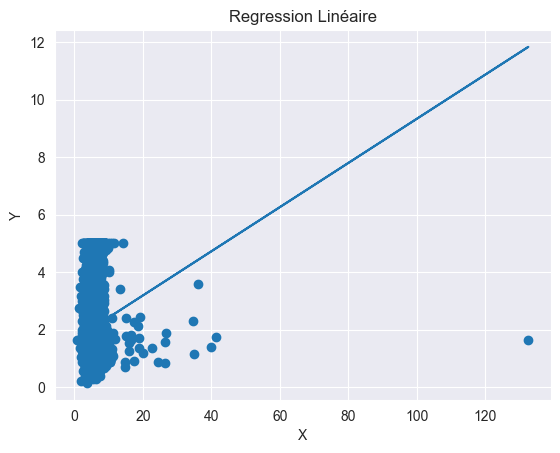

In [19]:
plt.scatter(X_test, y_test,) #Les données
plt.plot(X_test, y_pred) #la droite de regression
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regression Linéaire")
plt.show()

In [21]:
X = X[['MedInc', 'AveRooms']]

In [22]:
##Regression multiple
california_housing = fetch_california_housing()

X = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
y = pd.Series(california_housing.target)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [23]:
model.coef_

array([0.18323882])

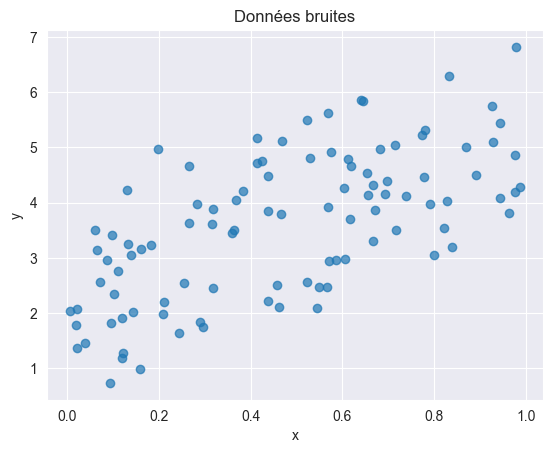

MSE : 0.9177532469714288
R2  : 0.29109095869239754


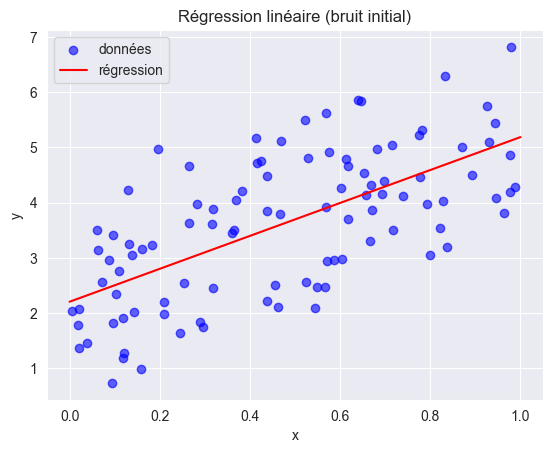

In [28]:
##Exercice1
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Données synthétiques
np.random.seed(0)
x = np.random.rand(100)          # (100,)
noise_scale = 1.0
eps = np.random.normal(loc=0, scale=noise_scale, size=x.shape)
y = 3 * x + 2 + eps

# 2. Mise en forme pour sklearn
X = x.reshape(-1, 1)

# 3. Visualisation des points
plt.scatter(x, y, alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Données bruites")
plt.show()

# 4. Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# MSE et R2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE :", mse)
print("R2  :", r2)

# 6. Tracer la droite de régression
x_grid = np.linspace(0, 1, 100).reshape(-1, 1)
y_grid = model.predict(x_grid)

plt.scatter(x, y, alpha=0.6, color='blue', label="données")
plt.plot(x_grid, y_grid, color="red", label="régression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Régression linéaire (bruit initial)")
plt.show()


In [25]:
np.random.seed(0)
noise_scale = 0.5   # moitié de la valeur précédente
eps2 = np.random.normal(loc=0, scale=noise_scale, size=x.shape)
y2 = 3 * x + 2 + eps2

X2 = x.reshape(-1, 1)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)

mse2 = mean_squared_error(y2_test, y2_pred)
r2_2 = r2_score(y2_test, y2_pred)
print("MSE (bruit/2) :", mse2)
print("R2  (bruit/2) :", r2_2)


MSE (bruit/2) : 0.2913955122008674
R2  (bruit/2) : 0.6724604470182491


Exercice2




In [26]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Charger le jeu de données
data = fetch_california_housing()
X = data.data          # features
y = data.target        # prix médians des maisons

# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Modèle Random Forest (config de base)
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Exercice 3

=== Gradient Boosting (baseline) ===
MSE train : 0.26080826071404806
R2  train : 0.8048978817773166
MSE test  : 0.2939973248643864
R2  test  : 0.7756446042829697
MedInc          -> 0.604
AveOccup        -> 0.123
Longitude       -> 0.110
Latitude        -> 0.099
HouseAge        -> 0.034
AveRooms        -> 0.024
AveBedrms       -> 0.005
Population      -> 0.001


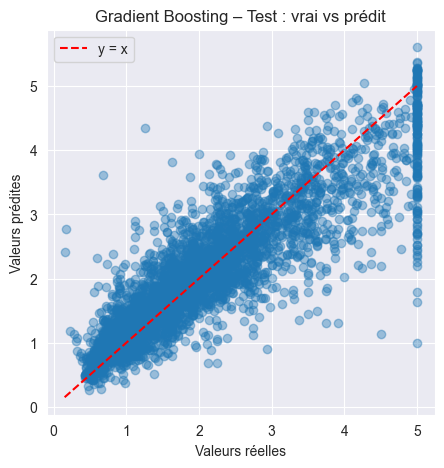

In [29]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Charger le dataset
data = fetch_california_housing()
X = data.data
y = data.target
feature_names = data.feature_names  # ['MedInc', 'HouseAge', ..., 'Longitude']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Modèle Gradient Boosting (baseline)
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

# Évaluation
y_train_pred = gb.predict(X_train)
y_test_pred = gb.predict(X_test)

print("=== Gradient Boosting (baseline) ===")
print("MSE train :", mean_squared_error(y_train, y_train_pred))
print("R2  train :", r2_score(y_train, y_train_pred))
print("MSE test  :", mean_squared_error(y_test, y_test_pred))
print("R2  test  :", r2_score(y_test, y_test_pred))

# 3. Importances des features
importances = gb.feature_importances_
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"{name:15s} -> {imp:.3f}")

# Plot vrai vs prédit (test)
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_test_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", label="y = x")
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Gradient Boosting – Test : vrai vs prédit")
plt.legend()
plt.show()


In [30]:
configs = [
    {"n_estimators": 100, "learning_rate": 0.1,  "max_depth": 3},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 4},
]

for cfg in configs:
    gb2 = GradientBoostingRegressor(
        n_estimators=cfg["n_estimators"],
        learning_rate=cfg["learning_rate"],
        max_depth=cfg["max_depth"],
        random_state=42
    )
    gb2.fit(X_train, y_train)
    y_test_pred2 = gb2.predict(X_test)

    mse_test2 = mean_squared_error(y_test, y_test_pred2)
    r2_test2 = r2_score(y_test, y_test_pred2)

    print(f"\nConfig: n_estimators={cfg['n_estimators']}, "
          f"learning_rate={cfg['learning_rate']}, max_depth={cfg['max_depth']}")
    print(f"MSE test : {mse_test2:.4f}   R2 test : {r2_test2:.4f}")



Config: n_estimators=100, learning_rate=0.1, max_depth=3
MSE test : 0.2940   R2 test : 0.7756

Config: n_estimators=300, learning_rate=0.05, max_depth=3
MSE test : 0.2719   R2 test : 0.7925

Config: n_estimators=500, learning_rate=0.03, max_depth=4
MSE test : 0.2474   R2 test : 0.8112
